In [1]:
import os
import sys
import skimage
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('../')
from microdet import mnds

# Bin the sizes

In [2]:
# Hyperparameters
# CURRENT_PATH = os.getcwd()
DIRECTORY = os.pardir + '/microdet/' + '/dataset_v2'
OUTPUT_DIR = "/model_output/output/"
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [3]:
DIRECTORY

'../microdet//dataset_v2'

In [4]:
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()
# annot_files = annot_files[0:10] # using all 18 images


training_files = annot_files.copy()
training_files

['20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-130.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-150.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-170.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-30.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png']

In [5]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
IoU_files = [file for file in filelist if file.endswith('._IoUs.npy')]
# pilot = [file for file in IoU_files if not file.startswith('C2-')]
# screen = [file for file in IoU_files if file.startswith('C2-')]
# print(len(pilot), len(screen))
print(len(IoU_files))
IoU_files

18


['20X_c0-DAPI_A1_Tile-10._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-110._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-130._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-150._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-170._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-190._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-30._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-50._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-70._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-90._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._IoUs.npy']

In [6]:
def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN


In [7]:
def generate_bins(start, end, step):
    bins = []
    for i in range(start, end-step+1, step):
        lst = [i, i+step]
        bins.append(lst)
    return bins
    
BIN_SIZE = generate_bins(0, 100, 5)
# BIN_SIZE = [[0,25], [25,50], [50, 75], [75,150]]
THRESHOLD = 0.5
BIN_SIZE

[[0, 5],
 [5, 10],
 [10, 15],
 [15, 20],
 [20, 25],
 [25, 30],
 [30, 35],
 [35, 40],
 [40, 45],
 [45, 50],
 [50, 55],
 [55, 60],
 [60, 65],
 [65, 70],
 [70, 75],
 [75, 80],
 [80, 85],
 [85, 90],
 [90, 95],
 [95, 100]]

In [14]:
matches[:-1,:].shape

(100, 84)

In [8]:
# Recall
df = pd.DataFrame(columns=['bins', 'metric', 'value'])
recall = []
  
for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(IoU_files)):
        path = DIRECTORY + OUTPUT_DIR + IoU_files[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = IoU_files[i].split('.')[0]
        mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
        gti = skimage.morphology.label(mn_gt)
        gt_area = []
        
        for j in range(matches.shape[0]):
            label_gt = j + 1
            area = np.sum(gti == label_gt)
            gt_area.append(area)
            
        matches = np.column_stack((matches, gt_area))
        matches= matches[matches[:, -1].argsort()]

        bin_matches = matches[(matches[:, -1] > bounds[0]) & (matches[:, -1] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:,:-1])
        if np.isnan(rec):
            recall.append(0)
        else:
            recall.append(rec)
        
    
    d = {'bins': [str(bounds)], 'metric': ['recall'], 'value':[np.mean(recall)]}
    df_sub = pd.DataFrame(data=d)
    df = pd.concat([df, df_sub], ignore_index=True)
    d = {} # empty the data
    print(f'(Average) Recall: {np.mean(recall):.2f}')

# Precision    
precision = []
for bounds in BIN_SIZE:
    print(f'Bin Size: {bounds}')
    
    for i in range(len(IoU_files)):
        path = DIRECTORY + OUTPUT_DIR + IoU_files[i]
        matches = np.load(path)
        matches = matches[:,:-1]

        imid = IoU_files[i].split('.')[0]
        prob_path = path.replace('_IoUs', '_probabilities')
        prob = np.load(prob_path)
        mn_pred = prob[0,:,:] > THRESHOLD
        pi = skimage.morphology.label(mn_pred)

        pred_area= []
        for j in range(matches.shape[1]): # along the columns
            label_pred = j + 1
            area = np.sum(pi == label_pred)
            pred_area.append(area)
            
        matches = np.row_stack((matches, pred_area))
        matches= matches[:, matches[-1, :].argsort()]


        bin_matches = matches[:, (matches[-1, :] > bounds[0]) & (matches[-1, :] < bounds[1])]
        f1, prec, rec, TP, FP, FN = measures_at(0.1, bin_matches[:-1,:])
        if np.isnan(prec):
            precision.append(0)
        else:
            precision.append(prec)
    
    d = {'bins': [str(bounds)], 'metric': ['precision'], 'value':[np.mean(precision)]}
    df_sub = pd.DataFrame(data=d)
    df = pd.concat([df, df_sub], ignore_index=True)
    d = {} # empty the data
    print(f'(Average) Precision: {np.mean(precision):.2f}')

Bin Size: [0, 5]


/tmp/ipykernel_2714187/3881663421.py:18: RuntimeWarning: invalid value encountered in scalar divide
  rec = TP / (TP + FN)
/tmp/ipykernel_2714187/1409866635.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_sub], ignore_index=True)


(Average) Recall: 0.00
Bin Size: [5, 10]
(Average) Recall: 0.11
Bin Size: [10, 15]
(Average) Recall: 0.18
Bin Size: [15, 20]
(Average) Recall: 0.31
Bin Size: [20, 25]
(Average) Recall: 0.40
Bin Size: [25, 30]
(Average) Recall: 0.48
Bin Size: [30, 35]
(Average) Recall: 0.54
Bin Size: [35, 40]
(Average) Recall: 0.58
Bin Size: [40, 45]
(Average) Recall: 0.61
Bin Size: [45, 50]
(Average) Recall: 0.64
Bin Size: [50, 55]
(Average) Recall: 0.66
Bin Size: [55, 60]
(Average) Recall: 0.68
Bin Size: [60, 65]
(Average) Recall: 0.70
Bin Size: [65, 70]
(Average) Recall: 0.71
Bin Size: [70, 75]
(Average) Recall: 0.71
Bin Size: [75, 80]
(Average) Recall: 0.70
Bin Size: [80, 85]
(Average) Recall: 0.71
Bin Size: [85, 90]
(Average) Recall: 0.70
Bin Size: [90, 95]
(Average) Recall: 0.70
Bin Size: [95, 100]
(Average) Recall: 0.70
Bin Size: [0, 5]
(Average) Precision: 0.72
Bin Size: [5, 10]
(Average) Precision: 0.74
Bin Size: [10, 15]
(Average) Precision: 0.74
Bin Size: [15, 20]
(Average) Precision: 0.74
Bi

/tmp/ipykernel_2714187/3881663421.py:16: RuntimeWarning: invalid value encountered in scalar divide
  prec = TP / (TP + FP)


(Average) Precision: 0.73
Bin Size: [40, 45]
(Average) Precision: 0.72
Bin Size: [45, 50]
(Average) Precision: 0.70
Bin Size: [50, 55]
(Average) Precision: 0.70
Bin Size: [55, 60]
(Average) Precision: 0.70
Bin Size: [60, 65]
(Average) Precision: 0.68
Bin Size: [65, 70]
(Average) Precision: 0.67
Bin Size: [70, 75]
(Average) Precision: 0.65
Bin Size: [75, 80]
(Average) Precision: 0.65
Bin Size: [80, 85]
(Average) Precision: 0.64
Bin Size: [85, 90]
(Average) Precision: 0.62
Bin Size: [90, 95]
(Average) Precision: 0.59
Bin Size: [95, 100]
(Average) Precision: 0.57


In [10]:
df

,bins,metric,value
0,"[0, 5]",recall,0.000000
1,"[5, 10]",recall,0.112103
2,"[10, 15]",recall,0.182496
3,"[15, 20]",recall,0.307571
4,"[20, 25]",recall,0.403204
5,"[25, 30]",recall,0.483512
6,"[30, 35]",recall,0.535515
7,"[35, 40]",recall,0.581770
8,"[40, 45]",recall,0.612441
9,"[45, 50]",recall,0.643480


In [11]:
# save it
df.to_csv('/scr/yren/binned_metric.csv')

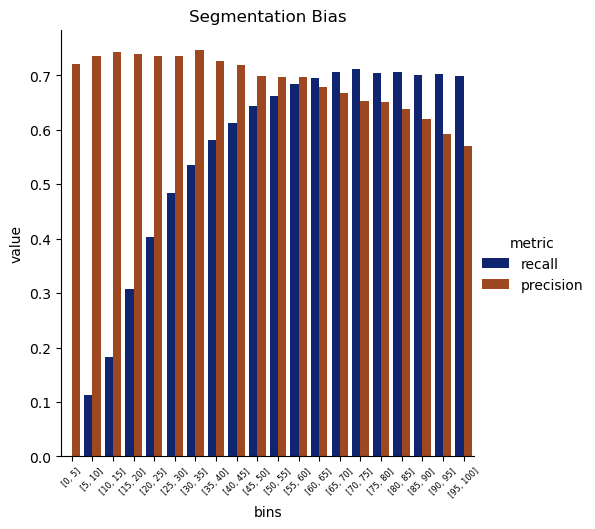

In [37]:
sns.catplot(
    data=df,
    kind='bar',
    x='bins',
    y='value',
    hue='metric',
    errorbar='sd',
    palette='dark'
)
plt.title('Segmentation Bias')
plt.xticks(fontsize=6)
plt.tick_params(axis='x', rotation=45)
plt.show()

In [4]:
annot_files

['20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-130.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-150.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-170.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-30.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-50.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype_outlines.png']

In [17]:
print(len(np.unique(gti)))
np.unique(gti)

97


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96], dtype=int32)

In [25]:
for i in annot_files:
    imid = i.split('.')[0]
    mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
    gti = skimage.morphology.label(mn_gt)
    
    gt_area = []
        
    for j in range(1, len(np.unique(gti))):
        area = np.sum(gti == j)
        gt_area.append(area)
    
    if (min(gt_area) < 5):
        print(f'{imid} - Found Micronuclei Size < 5')
    else:
        print(f'{imid} - No Micronuclei Size < 5')

20X_c0-DAPI_A1_Tile-10 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-110 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-130 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-150 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-170 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-190 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-30 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-50 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-70 - No Micronuclei Size < 5
20X_c0-DAPI_A1_Tile-90 - Found Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_A1_Tile-17 - No Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_A1_Tile-5 - No Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_A2_Tile-5 - No Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_A3_Tile-6 - No Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_B1_Tile-8 - No Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_B2_Tile-20 - Found Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_B3_Tile-10 - Found Micronuclei Size < 5
C2-20X_c0-DAPI-GFP_B3_Tile-16 - No Micronuclei Size < 5


In [24]:
min(gt_area)

8